# Marvel Comics — Regex Extraction & Writer Analysis

**Dataset:** `Marvel_Comics.csv` — 34,992 comic issues across ~4,935 series
**Author:** Waheed

This notebook uses Python's `re` (regular expressions) library to extract structured
information from a messy, real-world Marvel comics catalogue, then analyses the most
prolific writers. Two parts:

1. **Regex extraction** — most common series, superheroes and title words
2. **Writer analysis** — most prolific writers, the years they were active, and the
   superheroes they are most associated with

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Real-world file: not clean UTF-8, so read as latin-1
df = pd.read_csv("Marvel_Comics.csv", encoding="latin-1")

# Parse a usable year from the free-text publish_date ("August 10, 2016" -> 2016)
df["year"] = pd.to_datetime(df["publish_date"], errors="coerce").dt.year
# Some rows carry implausible/typo dates (e.g. 2029). Treat those as missing.
df.loc[(df["year"] < 1939) | (df["year"] > 2026), "year"] = float("nan")

print("Shape:", df.shape)
df.head(3)

Shape: (34992, 13)


,comic_name,active_years,issue_title,publish_date,issue_description,penciler,writer,cover_artist,Imprint,Format,Rating,Price,year
0,A Year of Marvels: April Infinite Comic (2016),(2016),A Year of Marvels: April Infinite Comic (2016) #1,"April 01, 2016",The Infinite Comic that will have everyone tal...,Yves Bigerel,Yves Bigerel,Jamal Campbell,Marvel Universe,Infinite Comic,Rated T+,Free,2016.0
1,A Year of Marvels: August Infinite Comic (2016),(2016),A Year of Marvels: August Infinite Comic (2016...,"August 10, 2016","Itâs August, and Nick Fury is just in time t...",Jamal Campbell,"Chris Sims, Chad Bowers",NaN,Marvel Universe,Infinite Comic,NaN,Free,2016.0
2,A Year of Marvels: February Infinite Comic (2016),(2016),A Year of Marvels: February Infinite Comic (20...,"February 10, 2016",Join us in a brand new Marvel comics adventure...,"Danilo S. Beyruth, M Mast",Ryan North,NaN,Marvel Universe,Infinite Comic,Rated T+,Free,2016.0


## Part 1 — Regex extraction

Three regex techniques:

- `r"\s*\(\d{4}.*?\)\s*$"` strips a trailing `(year)` / `(year - year)` from the series name.
- `re.escape(name)` matches hero names literally, so `-` in *Spider-Man* and `.` in *Ms. Marvel* are not treated as regex operators.
- `r"[A-Za-z][A-Za-z'\-]+"` tokenises titles into words while keeping hyphens, so `Spider-Man` stays intact.

In [2]:
# 1a. Most common series (strip the trailing year in parentheses)
year_suffix = re.compile(r"\s*\(\d{4}.*?\)\s*$")
df["series"] = df["comic_name"].apply(lambda s: year_suffix.sub("", str(s)).strip())
top_series = df["series"].value_counts().head(15)

# 1b. Most common superheroes (regex roster match against the series title)
heroes = ["Spider-Man","Iron Man","Captain America","Thor","Hulk","Wolverine",
          "X-Men","Avengers","Deadpool","Black Widow","Hawkeye","Black Panther",
          "Doctor Strange","Daredevil","Punisher","Ghost Rider","Fantastic Four",
          "Captain Marvel","Ant-Man","Star-Lord","Silver Surfer","Venom","Storm",
          "Cable","She-Hulk","Moon Knight","Blade","Nova","Namor","Doctor Doom"]
hero_pat = {h: re.compile(re.escape(h), re.IGNORECASE) for h in heroes}
names = df["comic_name"].dropna().astype(str)
hero_counts = {h: names.apply(lambda t: bool(p.search(t))).sum() for h, p in hero_pat.items()}
top_heroes = pd.Series(hero_counts).sort_values(ascending=False).head(15)

# 1c. Most common title words (regex tokenise + drop stopwords)
word_re = re.compile(r"[A-Za-z][A-Za-z'\-]+")
stop = {"the","and","of","vs","with","man"}
words = Counter()
for title in df["comic_name"].dropna().astype(str):
    for wd in word_re.findall(title):
        if wd.lower() not in stop and len(wd) > 2:
            words[wd.lower()] += 1
top_words = pd.Series(dict(words.most_common(15)))

print("Top series:\n", top_series, "\n")
print("Top superheroes:\n", top_heroes, "\n")
print("Top title words:\n", top_words)

Top series:
 series
Uncanny X-Men                               686
Fantastic Four                              682
Avengers                                    667
Daredevil                                   648
Captain America                             608
Thor                                        570
The Amazing Spider-Man                      543
Iron Man                                    454
Incredible Hulk                             425
Wolverine                                   361
X-Factor                                    280
Amazing Spider-Man                          277
Peter Parker, the Spectacular Spider-Man    271
X-Men                                       258
Deadpool                                    254
Name: count, dtype: int64 

Top superheroes:
 Spider-Man         3078
X-Men              2596
Avengers           2152
Fantastic Four     1071
Hulk               1034
Captain America    1000
Wolverine           951
Iron Man            879
Thor                86

**Interpretation — regex extraction.**
Spider-Man (~3,078 issues), the X-Men (~2,596) and the Avengers (~2,152) dominate the
catalogue. The individual-series view shows how a single hero is spread across many titles
(e.g. *The Amazing Spider-Man*, *Amazing Spider-Man*, *Peter Parker, the Spectacular
Spider-Man*), which is why the roster totals are much larger than any single series.
The purely data-driven title-word count also surfaces **`star` + `wars`** — a reminder that
Marvel publishes a large *Star Wars* line that a hero roster alone would miss.

## Part 2 — Most prolific writers

The `writer` field can hold several comma-separated names, so we split and *explode* it
to one writer per row before counting. For each writer we compute how many comics they
wrote, the span of years they were active, and the five superheroes they worked on most.

In [3]:
# Detect heroes per unique title once (reuse the roster from Part 1)
def find_heroes(title):
    t = str(title)
    return [h for h, p in hero_pat.items() if p.search(t)]
title_heroes = {t: find_heroes(t) for t in df["comic_name"].dropna().unique()}

# Explode multi-writer cells: "Chris Sims, Chad Bowers" -> two rows
w = df[["writer", "comic_name", "year"]].dropna(subset=["writer"]).copy()
w["writer"] = w["writer"].str.split(",")
w = w.explode("writer")
w["writer"] = w["writer"].str.strip()
w = w[(w["writer"] != "") & (~w["writer"].str.lower().isin(["various", "n/a"]))]

# Comics per writer + active-year range
agg = (w.groupby("writer")
        .agg(comics=("comic_name", "size"),
             first_year=("year", "min"),
             last_year=("year", "max"))
        .sort_values("comics", ascending=False))
agg["years_active"] = agg.apply(
    lambda r: f"{int(r.first_year)}-{int(r.last_year)}" if pd.notna(r.first_year) else "unknown",
    axis=1)

# Top 5 associated superheroes per writer
w["heroes"] = w["comic_name"].map(title_heroes)
wh = w.explode("heroes").dropna(subset=["heroes"])
top5 = (wh.groupby("writer")["heroes"]
          .apply(lambda s: ", ".join(s.value_counts().head(5).index)))

writers = agg.join(top5.rename("top_heroes"))[["comics", "years_active", "top_heroes"]]
writers.head(20)

,comics,years_active,top_heroes
writer,,,
Stan Lee,980,1941-2021,"Fantastic Four, Spider-Man, Thor, X-Men, Capta..."
Brian Michael Bendis,906,2000-2021,"Spider-Man, Avengers, X-Men, Iron Man, Daredevil"
Chris Claremont,823,1969-2021,"X-Men, Fantastic Four, Wolverine, Doctor Stran..."
Peter David,711,1985-2021,"Hulk, Spider-Man, Captain Marvel, She-Hulk, Wo..."
Roy Thomas,586,1965-2020,"Avengers, Doctor Strange, X-Men, Fantastic Fou..."
Tom Defalco,510,1978-2020,"Spider-Man, Fantastic Four, Thor, Avengers, Si..."
Fabian Nicieza,419,1988-2021,"Cable, Deadpool, X-Men, Avengers, Hawkeye"
Jason Aaron,399,2007-2021,"Thor, Wolverine, X-Men, Doctor Strange, Punisher"
Mark Waid,372,1994-2021,"Avengers, Daredevil, Captain America, Spider-M..."


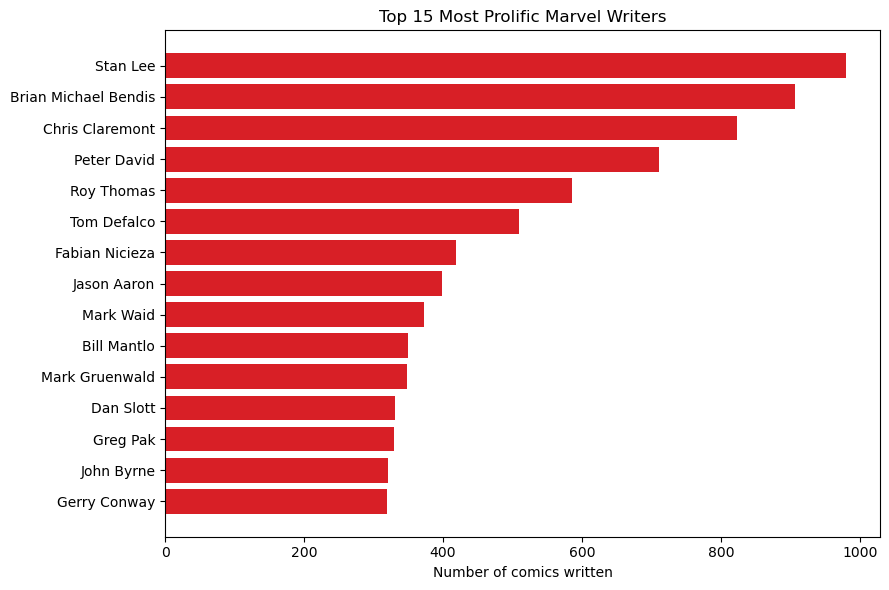

In [4]:
# Visualise the 15 most prolific writers
top15 = writers["comics"].head(15).iloc[::-1]
plt.figure(figsize=(9, 6))
plt.barh(top15.index, top15.values, color="#d81f26")   # Marvel red
plt.xlabel("Number of comics written")
plt.title("Top 15 Most Prolific Marvel Writers")
plt.tight_layout()
plt.show()

**Interpretation — writers.**
The ranking reads like a Marvel hall of fame. **Stan Lee** tops the list (~980 comics),
followed by **Brian Michael Bendis** and **Chris Claremont** — and the hero associations
line up perfectly with history: Lee with the Fantastic Four and Spider-Man he co-created,
Claremont with the X-Men run that defined the franchise, Peter David with the Hulk, and
Fabian Nicieza with Cable and Deadpool.

The `years_active` spans also tell a story (Lee's 1941-2021 reflects early Timely-era work
and posthumous reprints). Note this is a **data-cleaning caveat**: because `publish_date`
includes reprints and a few typo dates, the year spans can look longer than a writer's
actual active career — we already filtered out impossible future years, but reprint dates
still stretch the ranges.

## Summary

- **Regex** cleanly extracted series names, matched a superhero roster, and tokenised titles.
- **Spider-Man, X-Men and the Avengers** are the most-published franchises.
- The **most prolific writers** are Marvel legends (Lee, Bendis, Claremont), and their most
  associated heroes match their real-life signature runs.
- Real-world caveats remain: reprint dates inflate year ranges, and the hero roster is
  curated (a data-driven approach also surfaces the large *Star Wars* line).